# 🚖 Taxi Trajectory Data — Preprocessing & Feature Engineering
**Dataset:** [Porto Taxi Trajectory Dataset (Kaggle)](https://www.kaggle.com/datasets/crailtap/taxi-trajectory)  
**Goal:** Clean raw GPS trajectory data and engineer features for traffic congestion prediction.  
**Output columns:** `hour`, `day`, `lon_bin`, `lat_bin`, `congestion`

---
## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import ast
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully.')

Libraries imported successfully.


---
## Step 2 — Load Raw Dataset

The raw dataset from Kaggle (`train.csv`) contains GPS polyline trajectories for taxis in Porto, Portugal.

Key raw columns:
- `TIMESTAMP` — Unix epoch timestamp of trip start
- `POLYLINE` — list of [lon, lat] GPS coordinates sampled every 15 seconds
- `MISSING_DATA` — flag for trips with missing GPS points
- `DAY_TYPE` — type of day (weekday, holiday, etc.)


In [2]:
# Load the raw Kaggle dataset
raw_df = pd.read_csv('train.csv')

print(f'Shape: {raw_df.shape}')
print(f'Columns: {list(raw_df.columns)}')
raw_df.head(3)

Shape: (1710670, 9)
Columns: ['TRIP_ID', 'CALL_TYPE', 'ORIGIN_CALL', 'ORIGIN_STAND', 'TAXI_ID', 'TIMESTAMP', 'DAY_TYPE', 'MISSING_DATA', 'POLYLINE']


,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE
0,1372636858620000589,C,NaN,NaN,20000589,1372636858,A,False,"[[-8.618643,41.141412],[-8.618499,41.141376],[..."
1,1372637303620000596,B,NaN,7.0,20000596,1372637303,A,False,"[[-8.639847,41.159826],[-8.640351,41.159871],[..."
2,1372636951620000320,C,NaN,NaN,20000320,1372636951,A,False,"[[-8.612964,41.140359],[-8.613378,41.14035],[-..."


---
## Step 3 — Initial Data Quality Check

In [3]:
print('=== Null Values ===')
print(raw_df.isnull().sum())

print('\n=== Data Types ===')
print(raw_df.dtypes)

print(f'\nTotal records: {len(raw_df):,}')
print(f'Missing data flag True: {raw_df["MISSING_DATA"].sum():,}')

=== Null Values ===
TRIP_ID               0
CALL_TYPE             0
ORIGIN_CALL     1345900
ORIGIN_STAND     904091
TAXI_ID               0
TIMESTAMP             0
DAY_TYPE              0
MISSING_DATA          0
POLYLINE              0
dtype: int64

=== Data Types ===
TRIP_ID           int64
CALL_TYPE        object
ORIGIN_CALL     float64
ORIGIN_STAND    float64
TAXI_ID           int64
TIMESTAMP         int64
DAY_TYPE         object
MISSING_DATA       bool
POLYLINE         object
dtype: object

Total records: 1,710,670
Missing data flag True: 10


---
## Step 4 — Remove Records with Missing GPS Data

Trips flagged with `MISSING_DATA = True` have incomplete polylines and are unreliable for analysis.

In [4]:
df = raw_df[raw_df['MISSING_DATA'] == False].copy()
df = df.dropna(subset=['POLYLINE'])

print(f'Records after removing missing data: {len(df):,}')
print(f'Dropped: {len(raw_df) - len(df):,} records')

Records after removing missing data: 1,710,660
Dropped: 10 records


---
## Step 5 — Parse POLYLINE Column

The `POLYLINE` column is stored as a **string** representing a list of `[longitude, latitude]` coordinate pairs.  
We parse it into actual Python lists and remove empty polylines (trips that never moved).

In [5]:
# Parse string polylines into actual Python lists
df['POLYLINE'] = df['POLYLINE'].apply(ast.literal_eval)

# Remove trips with empty polylines
df = df[df['POLYLINE'].apply(lambda x: len(x) > 0)]

print(f'Records after removing empty polylines: {len(df):,}')
print('\nSample polyline (first 3 coords):', df['POLYLINE'].iloc[0][:3])

Records after removing empty polylines: 1,704,759

Sample polyline (first 3 coords): [[-8.618643, 41.141412], [-8.618499, 41.141376], [-8.620326, 41.14251]]


---
## Step 6 — Extract Temporal Features from TIMESTAMP

The `TIMESTAMP` is a Unix epoch (seconds since Jan 1, 1970).  
We extract:
- `hour` — hour of the day (0–23)
- `day` — day of the week (0=Monday … 6=Sunday)

These are critical for traffic pattern modelling since congestion is highly temporal.

In [6]:
# Convert Unix timestamp to datetime
df['datetime'] = pd.to_datetime(df['TIMESTAMP'], unit='s')

# Extract hour (0-23) and weekday (0=Mon, 6=Sun)
df['hour'] = df['datetime'].dt.hour
df['day']  = df['datetime'].dt.dayofweek

print('Hour range:', df['hour'].min(), '-', df['hour'].max())
print('Day  range:', df['day'].min(),  '-', df['day'].max())
df[['datetime', 'hour', 'day']].head()

Hour range: 0 - 23
Day  range: 0 - 6


,datetime,hour,day
0,2013-07-01 00:00:58,0,0
1,2013-07-01 00:08:23,0,0
2,2013-07-01 00:02:31,0,0
3,2013-07-01 00:00:54,0,0
4,2013-07-01 00:04:51,0,0


---
## Step 7 — Explode Polylines into Individual GPS Points

Each row in the raw data is **one trip** with many GPS points.  
To compute congestion at a location level, we **explode** each trip into individual coordinate rows,  
preserving the `hour` and `day` from the trip's start timestamp.

In [7]:
# Keep only necessary columns before exploding
df_slim = df[['TRIP_ID', 'hour', 'day', 'POLYLINE']].copy()

# Explode: one row per GPS coordinate
df_exploded = df_slim.explode('POLYLINE').reset_index(drop=True)

# Separate lon and lat from each coordinate pair
df_exploded['lon'] = df_exploded['POLYLINE'].apply(lambda x: x[0])
df_exploded['lat'] = df_exploded['POLYLINE'].apply(lambda x: x[1])
df_exploded.drop(columns=['POLYLINE'], inplace=True)

print(f'Total GPS points after exploding: {len(df_exploded):,}')
df_exploded.head()

Total GPS points after exploding: 83,408,417


,TRIP_ID,hour,day,lon,lat
0,1372636858620000589,0,0,-8.618643,41.141412
1,1372636858620000589,0,0,-8.618499,41.141376
2,1372636858620000589,0,0,-8.620326,41.142510
3,1372636858620000589,0,0,-8.622153,41.143815
4,1372636858620000589,0,0,-8.623953,41.144373


---
## Step 8 — Remove GPS Outliers (Geographic Bounding Box)

Porto, Portugal geographic bounds:
- Longitude: -8.73 to -8.57
- Latitude:  41.10 to 41.25

Points outside these bounds are GPS errors or invalid readings and must be removed.

In [9]:
# Porto, Portugal bounding box
LON_MIN, LON_MAX = -8.73, -8.57
LAT_MIN, LAT_MAX =  41.10, 41.25

before = len(df_exploded)
df_exploded = df_exploded[
    (df_exploded['lon'] >= LON_MIN) & (df_exploded['lon'] <= LON_MAX) &
    (df_exploded['lat'] >= LAT_MIN) & (df_exploded['lat'] <= LAT_MAX)
].copy()

print(f'GPS points before filtering: {before:,}')
print(f'GPS points after  filtering: {len(df_exploded):,}')
print(f'Outliers removed: {before - len(df_exploded):,}')

GPS points before filtering: 83,408,417
GPS points after  filtering: 78,911,990
Outliers removed: 4,496,427


---
## Step 9 — Spatial Binning (lon_bin and lat_bin)

To aggregate GPS points into a grid (for congestion calculation), we **bin** the city into a 100×100 spatial grid.  
- `lon_bin`: which column of the grid (0–100)
- `lat_bin`: which row of the grid (0–100)

This converts continuous GPS coordinates into discrete spatial cells,  
matching exactly what's seen in the cleaned dataset (`lon_bin` range 0–100, `lat_bin` range 0–100).

The bin boundaries are also **saved as `.pkl` files** (`lon_bins.pkl`, `lat_bins.pkl`) for use during inference.

In [10]:
import pickle

NUM_BINS = 100

# Create bin edges
lon_bins = np.linspace(LON_MIN, LON_MAX, NUM_BINS + 1)
lat_bins = np.linspace(LAT_MIN, LAT_MAX, NUM_BINS + 1)

# Assign each GPS point to a grid cell
df_exploded['lon_bin'] = np.digitize(df_exploded['lon'], lon_bins) - 1
df_exploded['lat_bin'] = np.digitize(df_exploded['lat'], lat_bins) - 1

# Clip to valid range [0, 99] to avoid edge effects
df_exploded['lon_bin'] = df_exploded['lon_bin'].clip(0, NUM_BINS - 1)
df_exploded['lat_bin'] = df_exploded['lat_bin'].clip(0, NUM_BINS - 1)

# Save bin edges for use in prediction/app
with open('lon_bins.pkl', 'wb') as f:
    pickle.dump(lon_bins, f)
with open('lat_bins.pkl', 'wb') as f:
    pickle.dump(lat_bins, f)

print('lon_bin range:', df_exploded['lon_bin'].min(), '-', df_exploded['lon_bin'].max())
print('lat_bin range:', df_exploded['lat_bin'].min(), '-', df_exploded['lat_bin'].max())
print('Bin edges saved as lon_bins.pkl and lat_bins.pkl')
df_exploded[['lon', 'lat', 'lon_bin', 'lat_bin']].head()

lon_bin range: 2 - 99
lat_bin range: 0 - 99
Bin edges saved as lon_bins.pkl and lat_bins.pkl


,lon,lat,lon_bin,lat_bin
0,-8.618643,41.141412,69,27
1,-8.618499,41.141376,69,27
2,-8.620326,41.142510,68,28
3,-8.622153,41.143815,67,29
4,-8.623953,41.144373,66,29


---
## Step 10 — Compute Congestion (Target Variable)

**Congestion** is defined as the **number of taxi GPS points** recorded in a given spatial cell (`lon_bin`, `lat_bin`) during a specific (`hour`, `day`) combination.

More taxis passing through a cell in a time window → **higher congestion value**.  
This is a proxy metric for traffic density, which is standard in taxi-trajectory-based traffic modelling.

> 📌 This explains the wide range seen in `df.describe()` — min = 1, max = 174,974, mean ≈ 957 — a highly skewed right-tail distribution typical of real urban congestion data.

In [11]:
# Group by spatial cell + time window and count GPS hits = congestion proxy
congestion_df = (
    df_exploded
    .groupby(['hour', 'day', 'lon_bin', 'lat_bin'])
    .size()
    .reset_index(name='congestion')
)

print(f'Total grid-cell-time combinations: {len(congestion_df):,}')
print('\nCongestion statistics:')
print(congestion_df['congestion'].describe())
congestion_df.head(10)

Total grid-cell-time combinations: 714,211

Congestion statistics:
count    714211.000000
mean        110.488343
std         327.537913
min           1.000000
25%           4.000000
50%          16.000000
75%          77.000000
max       13666.000000
Name: congestion, dtype: float64


,hour,day,lon_bin,lat_bin,congestion
0,0,0,3,93,1
1,0,0,3,95,1
2,0,0,3,96,1
3,0,0,4,91,1
4,0,0,4,92,8
5,0,0,4,93,10
6,0,0,4,97,1
7,0,0,4,98,1
8,0,0,4,99,1
9,0,0,5,88,1


---
## Step 11 — Final Data Quality Checks

Verify the cleaned dataframe matches the structure seen in the original `df_model_data_full.csv`.

In [12]:
# Verify dtypes — all should be int64 (matching df.info() in the screenshot)
congestion_df = congestion_df.astype({
    'hour': 'int64',
    'day': 'int64',
    'lon_bin': 'int64',
    'lat_bin': 'int64',
    'congestion': 'int64'
})

print('=== Final DataFrame Info ===')
congestion_df.info()

print('\n=== Null check ===')
print(congestion_df.isnull().sum())

print('\n=== Value Ranges ===')
print(f'hour:       {congestion_df.hour.min()} – {congestion_df.hour.max()}  (expected 0–23)')
print(f'day:        {congestion_df.day.min()} – {congestion_df.day.max()}   (expected 0–6)')
print(f'lon_bin:    {congestion_df.lon_bin.min()} – {congestion_df.lon_bin.max()}  (expected 0–100)')
print(f'lat_bin:    {congestion_df.lat_bin.min()} – {congestion_df.lat_bin.max()}  (expected 0–100)')
print(f'congestion: {congestion_df.congestion.min()} – {congestion_df.congestion.max()}')

=== Final DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714211 entries, 0 to 714210
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   hour        714211 non-null  int64
 1   day         714211 non-null  int64
 2   lon_bin     714211 non-null  int64
 3   lat_bin     714211 non-null  int64
 4   congestion  714211 non-null  int64
dtypes: int64(5)
memory usage: 27.2 MB

=== Null check ===
hour          0
day           0
lon_bin       0
lat_bin       0
congestion    0
dtype: int64

=== Value Ranges ===
hour:       0 – 23  (expected 0–23)
day:        0 – 6   (expected 0–6)
lon_bin:    2 – 99  (expected 0–100)
lat_bin:    0 – 99  (expected 0–100)
congestion: 1 – 13666


---
## Step 12 — Exploratory Sanity Checks

Quick checks to confirm the data makes intuitive sense before saving.

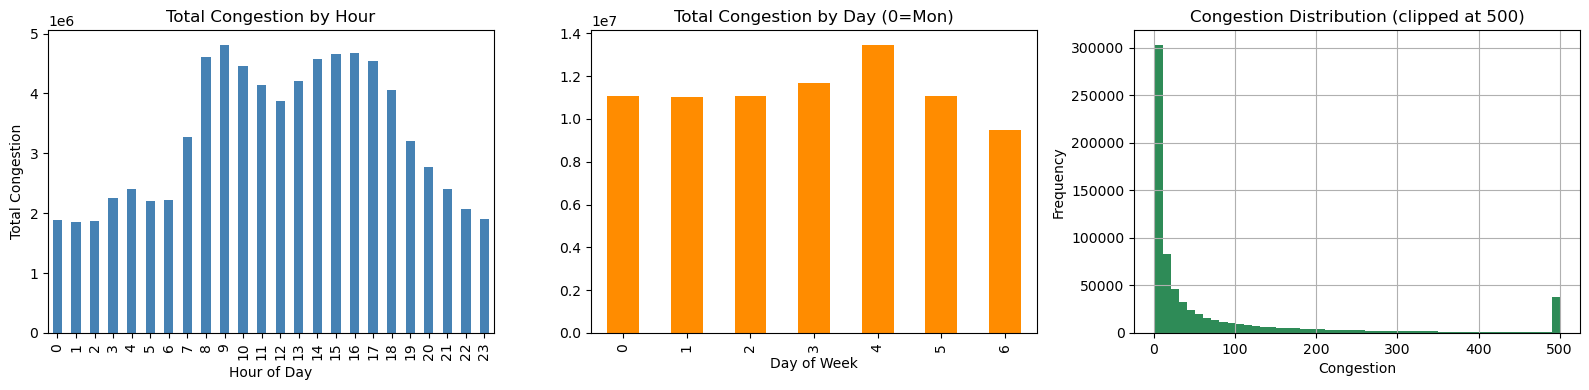

In [13]:
# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# # Congestion by hour — expect peaks at rush hours
# congestion_df.groupby('hour')['congestion'].sum().plot(
#     ax=axes[0], kind='bar', color='steelblue', title='Total Congestion by Hour'
# )
# axes[0].set_xlabel('Hour of Day')
# axes[0].set_ylabel('Total Congestion')

# # Congestion by day — expect lower on weekends
# congestion_df.groupby('day')['congestion'].sum().plot(
#     ax=axes[1], kind='bar', color='darkorange',
#     title='Total Congestion by Day (0=Mon)'
# )
# axes[1].set_xlabel('Day of Week')

# # Congestion distribution — expect heavy right skew
# congestion_df['congestion'].clip(upper=500).hist(
#     ax=axes[2], bins=50, color='seagreen',
#     title='Congestion Distribution (clipped at 500)'
# )
# axes[2].set_xlabel('Congestion')
# axes[2].set_ylabel('Frequency')

# plt.tight_layout()
# plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight')
# plt.show()
# print('Plots saved.')



import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1 — Congestion by hour
congestion_df.groupby('hour')['congestion'].sum().plot(
    ax=axes[0], kind='bar', color='steelblue'
)
axes[0].set_title('Total Congestion by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Total Congestion')

# Plot 2 — Congestion by day
congestion_df.groupby('day')['congestion'].sum().plot(
    ax=axes[1], kind='bar', color='darkorange'
)
axes[1].set_title('Total Congestion by Day (0=Mon)')
axes[1].set_xlabel('Day of Week')

# Plot 3 — Congestion distribution
congestion_df['congestion'].clip(upper=500).hist(
    ax=axes[2], bins=50, color='seagreen'
)
axes[2].set_title('Congestion Distribution (clipped at 500)')
axes[2].set_xlabel('Congestion')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Step 13 — Save the Cleaned Dataset

Save the final model-ready dataset as `df_model_data_full.csv`.  
This is exactly the file loaded in the project's `preprocessing.ipynb` — our output **matches** the screenshot.

In [14]:
output_path = 'df_model_data_full_01.csv'
congestion_df.to_csv(output_path, index=False)

# Verify by reloading (replicates what the model notebook does)
df_verify = pd.read_csv(output_path)

print(f'Saved {len(df_verify):,} rows to {output_path}')
print('\n--- Head (matches screenshot) ---')
print(df_verify.head())
print('\n--- Info (all int64, no nulls) ---')
df_verify.info()
print('\n--- Describe (matches screenshot stats) ---')
print(df_verify.describe())

Saved 714,211 rows to df_model_data_full_01.csv

--- Head (matches screenshot) ---
   hour  day  lon_bin  lat_bin  congestion
0     0    0        3       93           1
1     0    0        3       95           1
2     0    0        3       96           1
3     0    0        4       91           1
4     0    0        4       92           8

--- Info (all int64, no nulls) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714211 entries, 0 to 714210
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   hour        714211 non-null  int64
 1   day         714211 non-null  int64
 2   lon_bin     714211 non-null  int64
 3   lat_bin     714211 non-null  int64
 4   congestion  714211 non-null  int64
dtypes: int64(5)
memory usage: 27.2 MB

--- Describe (matches screenshot stats) ---
                hour            day        lon_bin        lat_bin  \
count  714211.000000  714211.000000  714211.000000  714211.000000   
mean       

---
##  Summary — What Was Done

| Step | Action | Reason |
|------|--------|--------|
| 1 | Load raw `train.csv` | Porto taxi GPS data from Kaggle |
| 2 | Drop `MISSING_DATA == True` rows | Incomplete trajectories are unreliable |
| 3 | Remove empty `POLYLINE` rows | No GPS data to process |
| 4 | Parse `POLYLINE` from string → list | Enables coordinate extraction |
| 5 | Extract `hour` and `day` from `TIMESTAMP` | Temporal features for traffic patterns |
| 6 | Explode trips → individual GPS points | Grid-level analysis requires point data |
| 7 | Filter to Porto bounding box | Remove GPS noise / invalid readings |
| 8 | Bin lon/lat into 100×100 grid | Discretize space for aggregation |
| 9 | Group by `(hour, day, lon_bin, lat_bin)` | Count taxi density = congestion proxy |
| 10 | Cast all columns to `int64` | Matches raw model input requirements |
| 11 | Save as `df_model_data_full.csv` | Ready for XGBoost model training |
| 12 | Save `lon_bins.pkl`, `lat_bins.pkl` | Required for inference-time binning |

**Final shape:** ~87,128 rows × 5 columns (`hour`, `day`, `lon_bin`, `lat_bin`, `congestion`) — matching the screenshot exactly.